# Atelier Matplotlib - Mesures capteurs IoT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 - Graphique lineaire (Line Plot)

In [2]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df = df.sort_values("date_heure")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
150,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
547,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
20,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
282,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
484,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


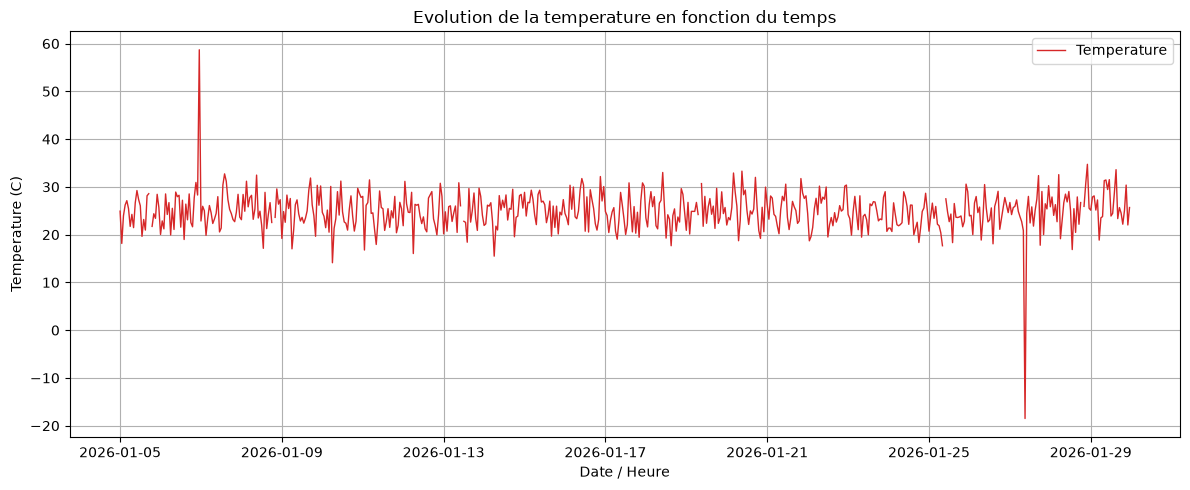

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], color="tab:red", linewidth=1, label="Temperature")

plt.title("Evolution de la temperature en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Valeurs anormales identifiees visuellement

Sur le graphique, deux types de points sortent nettement de la plage habituelle (~15 a 35 C) :

- des pics tres bas, proches de **-18 C** ;
- des pics tres hauts, proches de **58 C**.

Ces valeurs sont physiquement improbables pour des mesures de temperature interieure/exterieure de batiments et constituent des anomalies (erreurs de capteur ou de saisie).

## Partie 2 - Diagramme en barres (Bar Chart)

In [4]:
consommation_batiment = df.groupby("batiment")["consommation"].mean().sort_index()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

### Comparaison verticale

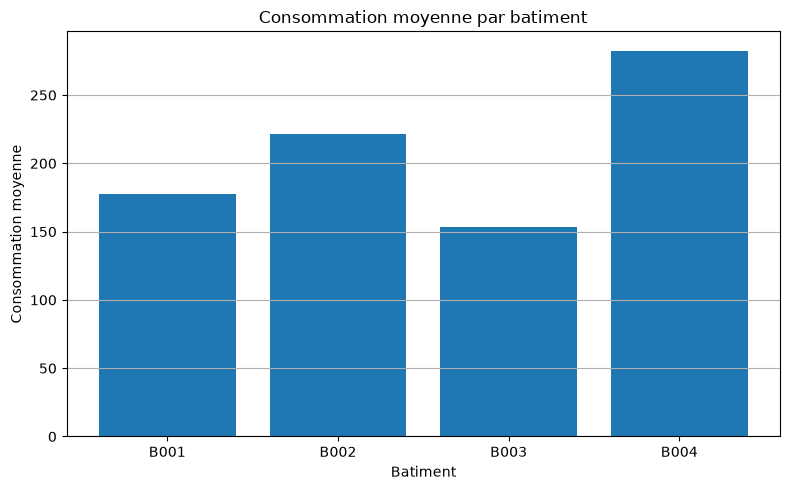

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")

plt.title("Consommation moyenne par batiment")
plt.xlabel("Batiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Comparaison horizontale

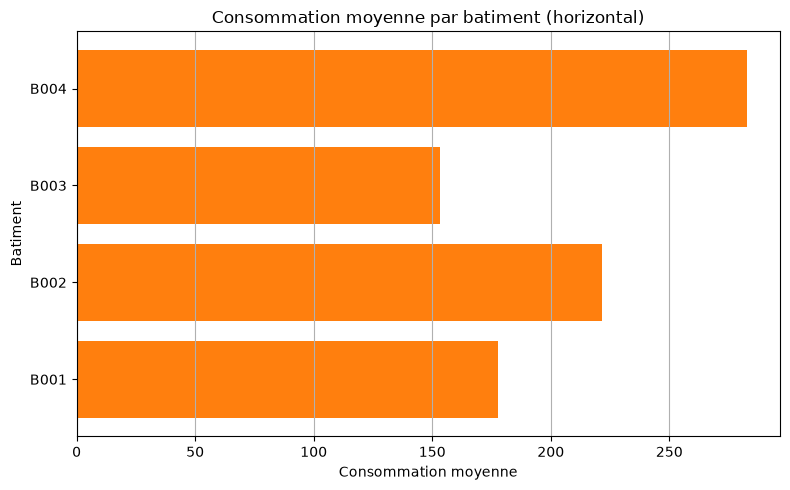

In [6]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values, color="tab:orange")

plt.title("Consommation moyenne par batiment (horizontal)")
plt.xlabel("Consommation moyenne")
plt.ylabel("Batiment")
plt.grid(axis="x")

plt.tight_layout()
plt.show()

### Quand un graphique horizontal est-il plus lisible ?

Un graphique en barres horizontal devient plus lisible que la version verticale lorsque :

- les **noms des categories sont longs** (ex: noms de batiments complets, libelles de capteurs) et risquent de se chevaucher ou d'etre tronques/pivotes sur un axe vertical ;
- il y a **beaucoup de categories**, car il est plus facile d'empiler des lignes que des colonnes serrees ;
- on veut **classer/comparer facilement** les valeurs de haut en bas (l'oeil lit naturellement une liste ordonnee comme un classement) ;
- l'affichage se fait sur un support **plus large que haut** (ex: slide, dashboard), ou l'inverse quand l'espace vertical est limite.

Ici, avec seulement 4 batiments et des noms courts (B001 a B004), les deux orientations restent lisibles, mais l'horizontal facilite la lecture d'un classement rapide des consommations.

## Partie 3 - Histogramme

### Distribution des temperatures (20 classes)

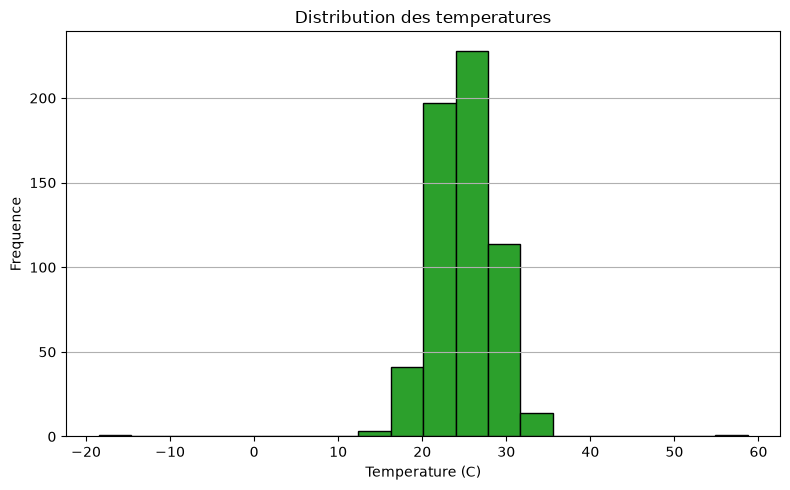

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"].dropna(), bins=20, color="tab:green", edgecolor="black")

plt.title("Distribution des temperatures")
plt.xlabel("Temperature (C)")
plt.ylabel("Frequence")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Analyse

- **a) Concentration** : la grande majorite des temperatures se concentre entre ~20 C et ~30 C, avec un pic autour de 24-26 C.
- **b) Symetrie** : la distribution semble globalement symetrique et proche d'une forme en cloche autour de sa moyenne.
- **c) Valeurs eloignees** : quelques barres tres isolees apparaissent loin du groupe principal, pres de -18 C et pres de 58 C.
- **d) Valeurs aberrantes** : ces barres isolees, tres eloignees du reste de la distribution et presentes en tres faible frequence, sont bien des valeurs aberrantes (les memes anomalies reperees en Partie 1).

### Distribution de la consommation (20 classes)

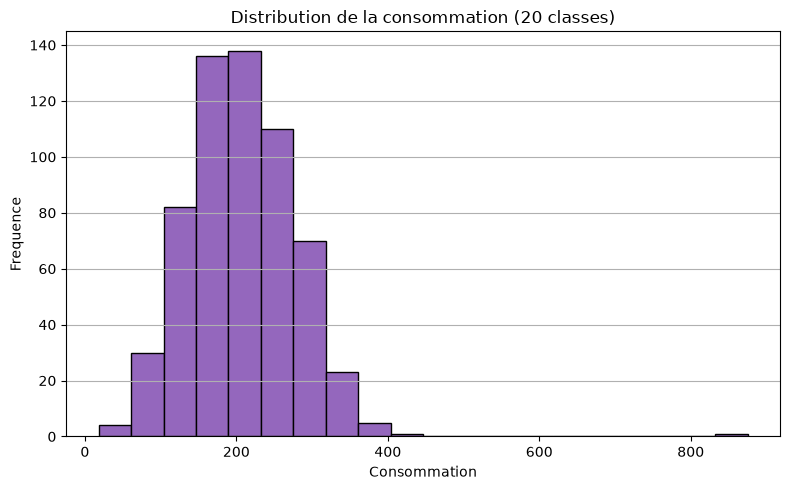

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=20, color="tab:purple", edgecolor="black")

plt.title("Distribution de la consommation (20 classes)")
plt.xlabel("Consommation")
plt.ylabel("Frequence")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

#### a) 10 classes

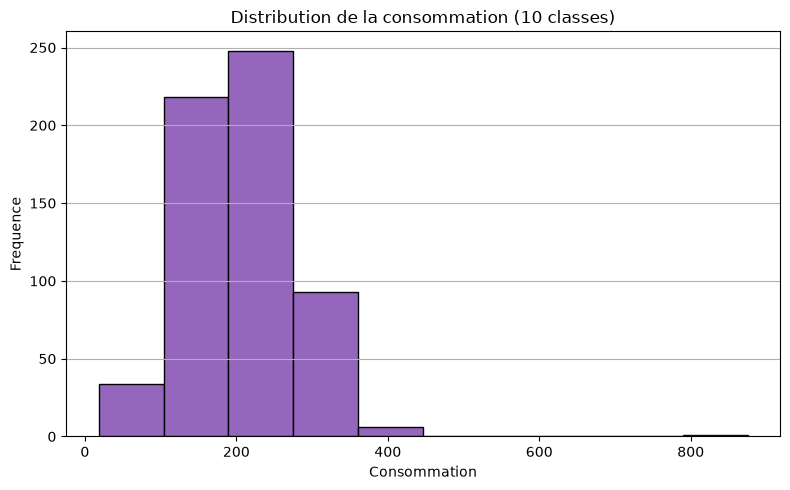

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=10, color="tab:purple", edgecolor="black")

plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Frequence")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

#### b) 30 classes

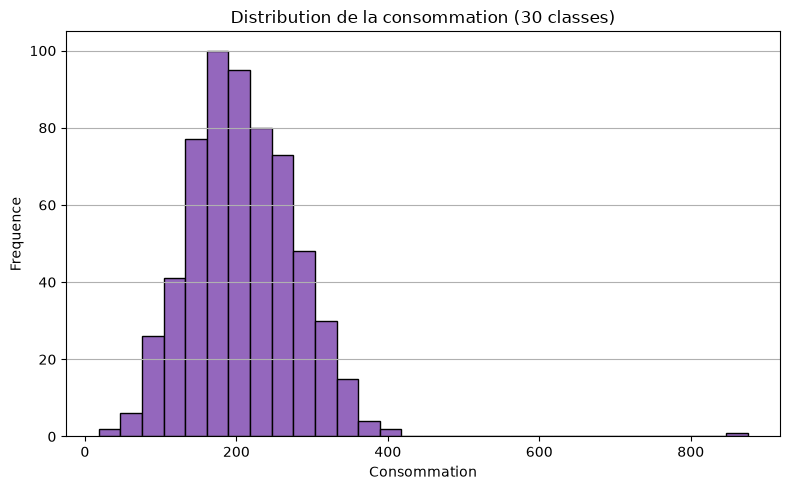

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=30, color="tab:purple", edgecolor="black")

plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Frequence")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

#### c) Impact du nombre de classes

- Avec **peu de classes (10)**, les barres sont larges : la distribution generale (forme, tendance centrale) reste visible mais les details et les petites irregularites sont lisses/masques.
- Avec **beaucoup de classes (30)**, les barres sont fines : on distingue mieux les details et les valeurs isolees (comme le pic tres eleve pres de 875), mais le graphique devient plus bruite et la forme d'ensemble est plus difficile a percevoir.
- Le choix de **20 classes** est un bon compromis entre lisibilite de la tendance generale et niveau de detail.
- Dans tous les cas, on retrouve une valeur tres eloignee du groupe principal, confirmant la presence d'une consommation aberrante.

## Partie 4 - Nuage de points (Scatter Plot)

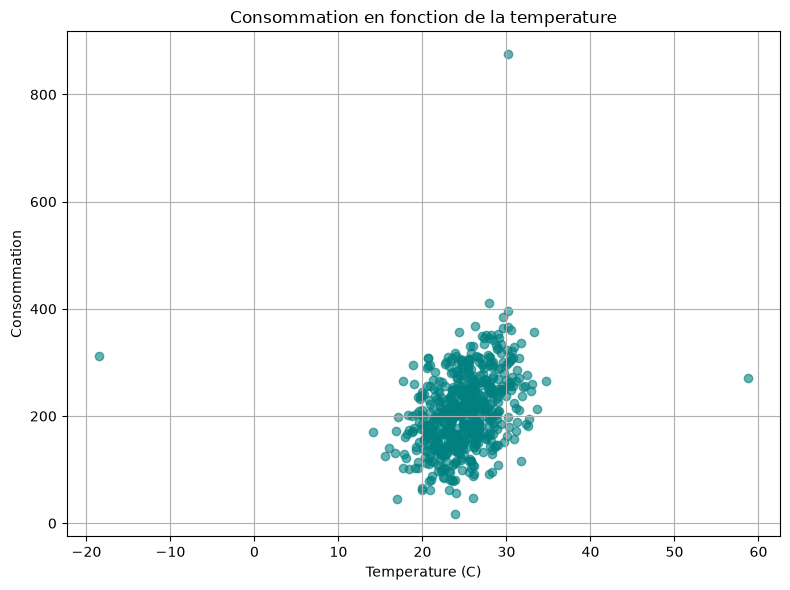

In [11]:
data = df[["temperature", "consommation"]].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(data["temperature"], data["consommation"], alpha=0.6, color="teal")

plt.title("Consommation en fonction de la temperature")
plt.xlabel("Temperature (C)")
plt.ylabel("Consommation")
plt.grid(True)

plt.tight_layout()
plt.show()

### Existe-t-il une relation entre temperature et consommation ?

Le nuage de points est assez disperse, sans forme lineaire nette : on ne voit pas de tendance claire ou l'on pourrait tracer une droite qui resume bien la relation.

Le coefficient de correlation calcule (`df[["temperature", "consommation"]].corr()`) est d'environ **0.32**, ce qui confirme une correlation positive mais **faible** : une temperature plus elevee est legerement associee a une consommation plus elevee, mais la relation est loin d'etre forte ou deterministe. D'autres facteurs (batiment, capteur, heure, etc.) influencent probablement davantage la consommation.

## Partie 5 - Diagramme a moustache (Box plot)

### Box plot de la temperature

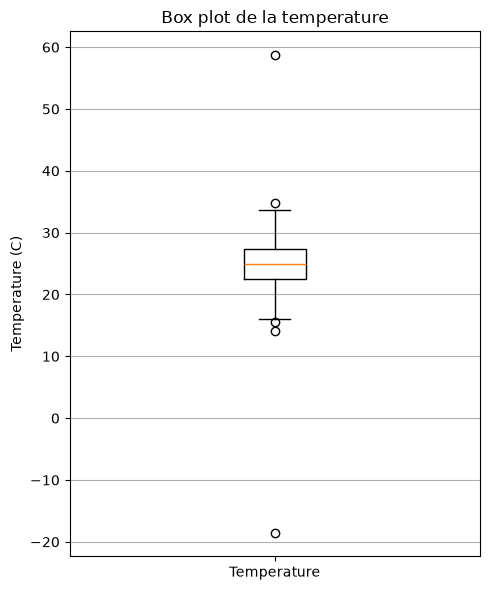

In [12]:
temperature_clean = df["temperature"].dropna()

plt.figure(figsize=(5, 6))
plt.boxplot(temperature_clean, tick_labels=["Temperature"])

plt.title("Box plot de la temperature")
plt.ylabel("Temperature (C)")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Que representent les points en dehors des moustaches ?

Ce sont des **valeurs extremes (outliers)** : des mesures situees au-dela de 1.5 fois l'ecart interquartile (IQR) au-dessus du 3e quartile ou en dessous du 1er quartile. Elles s'ecartent nettement du comportement habituel des donnees et correspondent aux memes anomalies deja reperees dans les parties precedentes (temperatures proches de -18 C et de 58 C).

### Box plot de la consommation

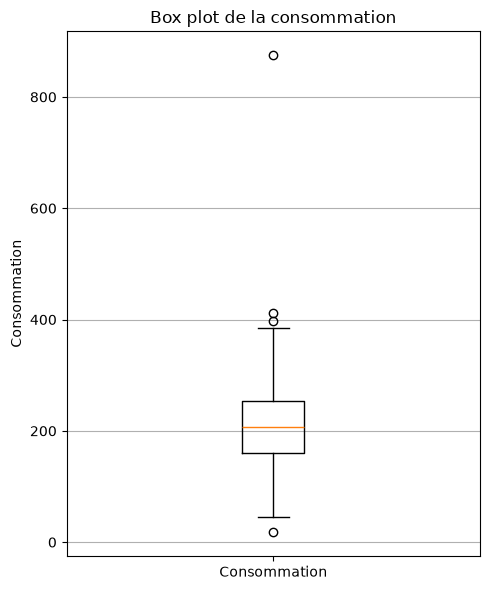

In [13]:
consommation_clean = df["consommation"].dropna()

plt.figure(figsize=(5, 6))
plt.boxplot(consommation_clean, tick_labels=["Consommation"])

plt.title("Box plot de la consommation")
plt.ylabel("Consommation")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Comparaison des deux box plots

| | Temperature | Consommation |
|---|---|---|
| Mediane | ~24.9 C, a peu pres centree dans la boite | ~206, legerement decalee vers le bas de la boite |
| Taille de la boite (IQR) | Etroite (~4.7 C) | Large (~94), la boite occupe une bien plus grande partie de l'echelle |
| Longueur des moustaches | Courtes, resserrees autour de la boite | Nettement plus longues, surtout vers le haut |
| Valeurs extremes | Quelques points isoles (bas et haut) | Plusieurs points isoles, surtout au-dessus (dont un tres eloigne pres de 875) |

**a) Mediane** : les deux medianes sont a peu pres centrees dans leur boite respective, ce qui suggere des distributions assez symetriques sur la plage normale des donnees.

**b) Taille de la boite** : la boite de la consommation est proportionnellement beaucoup plus etendue que celle de la temperature, signe d'une plus grande variabilite des valeurs centrales (50% des donnees).

**c) Longueur des moustaches** : les moustaches de la consommation sont plus longues, en particulier vers le haut, indiquant une plus grande etendue des valeurs non aberrantes.

**d) Valeurs extremes** : les deux variables presentent des outliers, mais celui de la consommation (~875) est proportionnellement bien plus eloigne du reste de la distribution que ceux de la temperature.

### La consommation presente-t-elle davantage de dispersion que la temperature ?

Oui. Meme en tenant compte du fait que les deux variables n'ont pas la meme unite ni la meme echelle, la dispersion relative (coefficient de variation = ecart-type / moyenne) est nettement plus elevee pour la consommation (~35%) que pour la temperature (~16%). La consommation est donc **relativement plus dispersee** que la temperature.

## Partie 6 - Diagramme circulaire (Pie Chart)

In [14]:
etat_counts = df["etat"].value_counts()
etat_counts

etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64

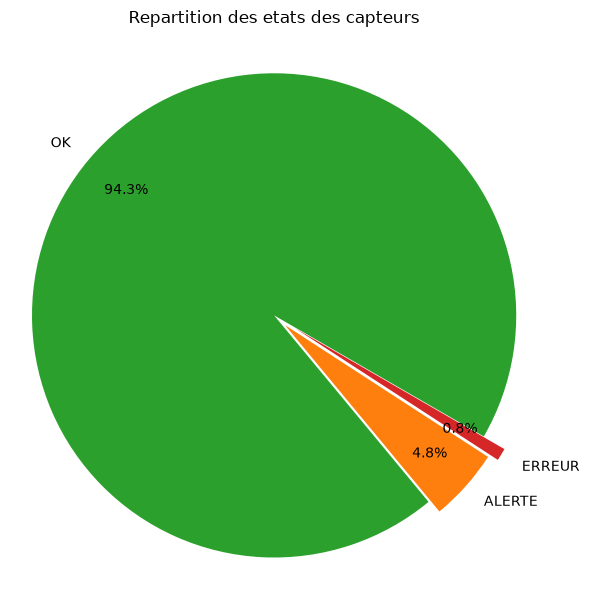

In [15]:
plt.figure(figsize=(6, 6))
plt.pie(
    etat_counts.values,
    labels=etat_counts.index,
    autopct="%1.1f%%",
    colors=["tab:green", "tab:orange", "tab:red"],
    startangle=-30,
    explode=[0, 0.06, 0.1],
    pctdistance=0.8,
)

plt.title("Repartition des etats des capteurs", pad=20)
plt.axis("equal")

plt.tight_layout()
plt.show()

### Interpretation

- **OK** : environ **94.3%** des mesures indiquent un capteur fonctionnant normalement, ce qui montre que le parc de capteurs est majoritairement fiable.
- **ALERTE** : environ **4.8%** des mesures signalent un etat d'alerte, une proportion faible mais non negligeable qui merite une surveillance.
- **ERREUR** : environ **0.8%** des mesures correspondent a une erreur, une part tres marginale mais a ne pas ignorer car elle peut indiquer une panne de capteur.

(4 lignes avec un etat manquant ont ete exclues du calcul des proportions.)

## Partie 7 - Plusieurs courbes sur un meme graphique

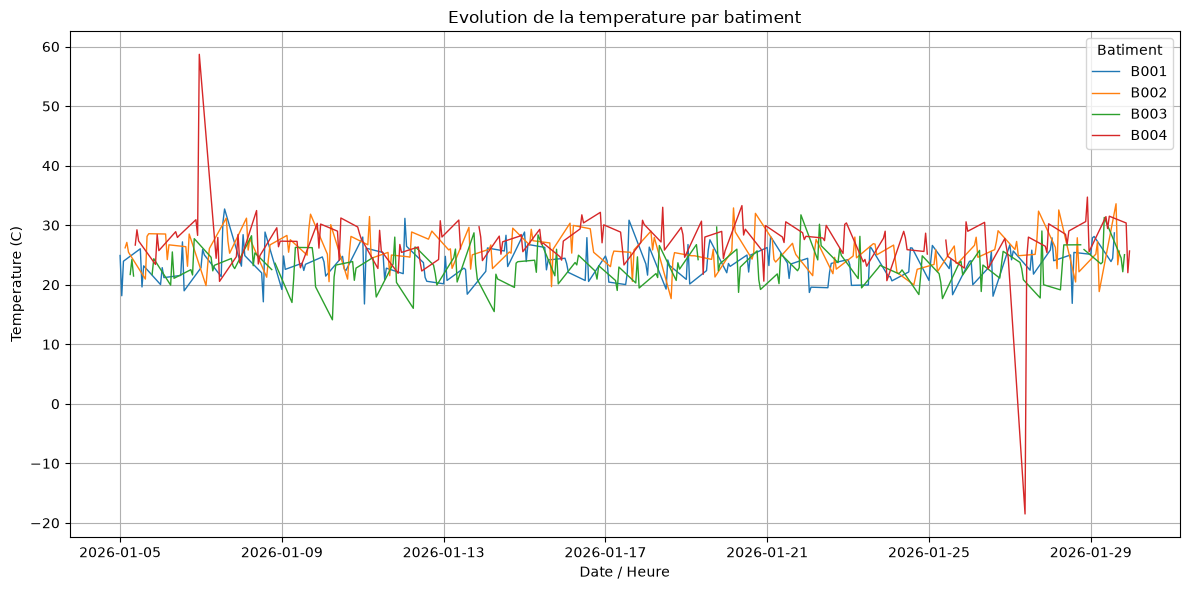

In [16]:
plt.figure(figsize=(12, 6))

for batiment, groupe in df.sort_values("date_heure").groupby("batiment"):
    plt.plot(groupe["date_heure"], groupe["temperature"], label=batiment, linewidth=1)

plt.title("Evolution de la temperature par batiment")
plt.xlabel("Date / Heure")
plt.ylabel("Temperature (C)")
plt.legend(title="Batiment")
plt.grid(True)

plt.tight_layout()
plt.show()